# CS614 Final Project — AI Industrial Quality Inspector (NEU Surface Defects)
## Roy Phelps

## Dataset

This project uses the **NEU Surface Defect Database**, a publicly available dataset of hot-rolled steel surface defects.

Classes:
- crazing
- inclusion
- patches
- pitted_surface
- rolled-in_scale
- scratches

Dataset source:  
https://www.kaggle.com/datasets/bobweng/neu-surface-defect-dataset

## Outline
1. Problem and Pitch
2. Dataset and Setup
3. Exploratory Checks (Samples and Balance)
4. Model Setup (ResNet18 fine-tuning)
5. Training
6. Evaluation (Loss, Accuracy, and Confusion Matrix)
7. Demo and Predictions
8. Grad-CAM Explainability
9. Discussion
10. Reproducibility

# 1. Problem and Pitch


## Pitch (Problem → Solution)
Manual surface inspection in manufacturing is often slow, labor-intensive, and inconsistent. This project presents a proof-of-concept computer vision model that classifies steel surface defect types and can be extended with visual explanations such as **Grad-CAM** to improve interpretability and trust.

### Technical Approach

This project follows **Option 2 from the course guidelines: fine-tuning a pretrained deep learning model on a new dataset.**

We use a pretrained **ResNet18 convolutional neural network** (originally trained on ImageNet) and adapt it to classify six surface defect types from the NEU Surface Defect dataset.

Key components of the approach include:

- Transfer learning using ResNet18
- Data preprocessing and augmentation
- Training and validation performance evaluation
- Confusion matrix analysis
- **Grad-CAM visual explanations to highlight defect regions**

### Market Gap

Manual inspection of manufacturing surfaces is often:

- slow
- subjective
- inconsistent across operators

AI-based inspection systems can improve speed and consistency, but many industrial systems lack **explainability**.

By combining **transfer learning with Grad-CAM visualization**, this project demonstrates a low-cost proof-of-concept that not only classifies defects but also highlights **where the model is focusing in the image**.

# 2. Dataset and Setup

## Import Statements

In [20]:
# Import
# NOTE: Some imports like the confusion matrix will be used later during evaluation.
import os
from pathlib import Path
import random

from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
from torchvision import datasets, transforms

## Dataset & Folder Structure

**Dataset:** NEU Surface Defects (Kaggle version)

The dataset is organized into training and validation folders containing images for each defect class.

Expected directory structure:
```
data/raw/neu_surface_defects/NEU-DET/
├── train/
│ └── images/
│ ├── crazing/
│ ├── inclusion/
│ ├── patches/
│ ├── pitted_surface/
│ ├── rolled-in_scale/
│ └── scratches/
│
└── validation/
└── images/
├── crazing/
├── inclusion/
├── patches/
├── pitted_surface/
├── rolled-in_scale/
└── scratches/
```

The dataset is loaded using **torchvision.datasets.ImageFolder**, which expects one folder per class label.

In [3]:
# Setting seeds to reproduce fixing random seeds helps
# to make results consistent across runs.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> project root

DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "neu_surface_defects" / "NEU-DET"

TRAIN_DIR = DATASET_ROOT / "train" / "images"
VAL_DIR   = DATASET_ROOT / "validation" / "images"

# Check: confirm dataset paths exist before attempting to load images. 
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_ROOT:", DATASET_ROOT)
print("TRAIN_DIR exists?:", TRAIN_DIR.exists())
print("VAL_DIR exists?:", VAL_DIR.exists())

PROJECT_ROOT: /Users/royphelps/Library/CloudStorage/OneDrive-DrexelUniversity/CS-614-900/Assignments/Final Project/CS614-AI-Industrial-Quality-Inspector
DATASET_ROOT: /Users/royphelps/Library/CloudStorage/OneDrive-DrexelUniversity/CS-614-900/Assignments/Final Project/CS614-AI-Industrial-Quality-Inspector/data/raw/neu_surface_defects/NEU-DET
TRAIN_DIR exists?: True
VAL_DIR exists?: True


## Loading the Dataset with ImageFolder

PyTorch’s `ImageFolder` class automatically assigns numeric labels to images based on their folder names. This makes it convenient to load datasets for classification tasks where images are organized into class-specific directories.

For this initial exploration stage, we apply **basic image preprocessing**:

- Resize images to **224 × 224** (required by ResNet18)
- Convert images to **PyTorch tensors**

Later, when training the model, we will extend these transforms to include **ImageNet normalization and data augmentation** to improve generalization.

In [4]:
# Basic transforms for exploration to resize + tensor conversion.
# For pretrained ResNet fine tuning, we will later add ImageNet normalization and augmentations.

basic_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(root=str(TRAIN_DIR), transform=basic_tfms)
val_ds   = datasets.ImageFolder(root=str(VAL_DIR), transform=basic_tfms)

print("Train images:", len(train_ds))
print("Val images:", len(val_ds))

print("Num classes:", len(train_ds.classes))
print("Classes:", train_ds.classes)

# Verify both datasets use identical class index mapping
print("Same class mapping?", train_ds.class_to_idx == val_ds.class_to_idx)

Train images: 1440
Val images: 360
Num classes: 6
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Same class mapping? True


# 3. Exploratory Checks (Samples and Balance)

### Visual Inspection of Samples

Before training a model, it is important to visually inspect a subset of images to verify that:

- Images load correctly
- Labels match the expected defect classes
- Surface defects are visually distinguishable

This quick visualization step helps confirm that the dataset has been loaded correctly and that preprocessing transforms are functioning as expected.

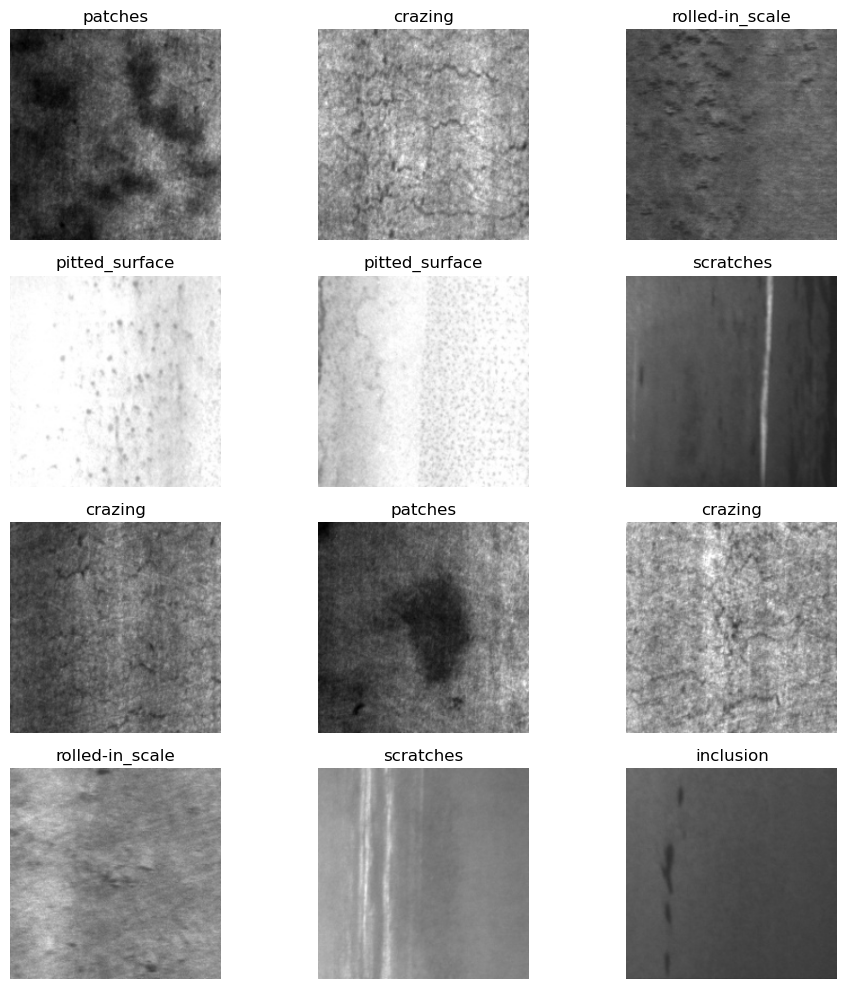

In [8]:
# Display random sample images from the dataset

def show_samples(ds, n=12, seed=42):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(ds), size=n, replace=False)

    cols = 3
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(10, 10))

    for i, idx in enumerate(idxs, start=1):
        x, y = ds[idx]  # Tensor CHW, label index
        img = x.permute(1, 2, 0).numpy()  # CHW -> HWC conversion
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(ds.classes[y])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_ds, n=12)

## Class Distribution Analysis

Balanced datasets are important when training classification models.  
If one class dominates the dataset, the model may become biased toward predicting that class more frequently.

The NEU Surface Defect dataset is intentionally **well balanced**, which simplifies training and evaluation.  
To confirm this, we compute the number of images per class in both the **training** and **validation** sets and visualize the distribution.

Train counts:
         crazing: 240
       inclusion: 240
         patches: 240
  pitted_surface: 240
  rolled-in_scale: 240
       scratches: 240

Validation counts:
         crazing: 60
       inclusion: 60
         patches: 60
  pitted_surface: 60
  rolled-in_scale: 60
       scratches: 60


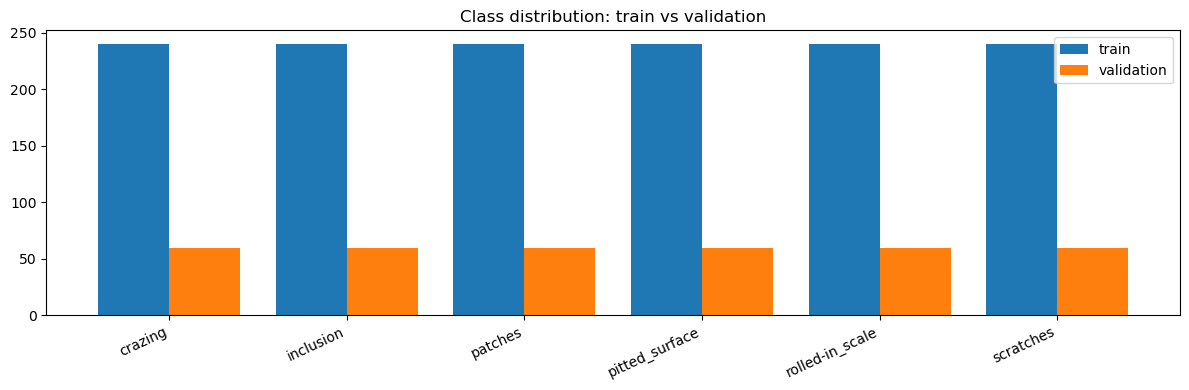

In [9]:
# ImageFolder automatically maps folder names to class labels

def class_counts(imagefolder_ds):
    targets = [y for _, y in imagefolder_ds.samples]
    counts = np.bincount(targets, minlength=len(imagefolder_ds.classes))
    return counts

train_counts = class_counts(train_ds)
val_counts   = class_counts(val_ds)

print("Train counts:")
for cls, cnt in zip(train_ds.classes, train_counts):
    print(f"  {cls:>14}: {cnt}")

print("\nValidation counts:")
for cls, cnt in zip(val_ds.classes, val_counts):
    print(f"  {cls:>14}: {cnt}")

# Plot side-by-side bars 
x = np.arange(len(train_ds.classes))
width = 0.4

plt.figure(figsize=(12,4))
plt.bar(x - width/2, train_counts, width, label="train")
plt.bar(x + width/2, val_counts, width, label="validation")

plt.xticks(x, train_ds.classes, rotation=25, ha="right")
plt.title("Class distribution: train vs validation")
plt.legend()
plt.tight_layout()

# Ensure output directory exists
FIG_PATH = PROJECT_ROOT / "outputs" / "figures" / "balance.png"
FIG_PATH.parent.mkdir(parents=True, exist_ok=True)

# Save the chart in the outputs folder
FIG_PATH = PROJECT_ROOT / "outputs" / "figures" / "balance.png"
plt.savefig(FIG_PATH, dpi=300, bbox_inches="tight")

plt.show()

## 4. Model Development 

The next stage of the project is to **fine-tune a pretrained convolutional neural network (ResNet18)** on the NEU surface defect dataset.

### Model Development Steps

1. Create **DataLoaders** to batch images for training and validation  
2. Load a **pretrained ResNet18 model** (trained on ImageNet)  
3. Replace the **final classification layer** to output 6 defect classes  
4. Train the model using the training dataset  
5. Evaluate performance on the validation dataset  

# 4. Model Setup (ResNet18 fine-tuning)

## Image Preprocessing for Training

Pretrained models such as ResNet18 expect images that follow the **ImageNet normalization scheme**.

We also apply **light data augmentation** during training to improve generalization:

- Random horizontal flips
- Small random rotations

Validation data is not augmented so that evaluation metrics remain consistent.

In [10]:
# Transforms for training a pretrained ResNet model

train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),

    # ImageNet normalization required for pretrained ResNet models
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Reload Datasets with Training Transforms

Earlier, we loaded the dataset using **basic transforms** for exploration.

Now we reload the datasets using the **training transforms** defined above:

- Training images use **data augmentation + ImageNet normalization**
- Validation images use **ImageNet normalization only**

This ensures that the model receives properly normalized inputs while preserving a clean validation evaluation pipeline.

In [11]:
train_ds = datasets.ImageFolder(
    root=str(TRAIN_DIR),
    transform=train_tfms
)

val_ds = datasets.ImageFolder(
    root=str(VAL_DIR),
    transform=val_tfms
)

## Creating DataLoaders

PyTorch **DataLoaders** handle batching, shuffling, and efficient loading of images during training.

Using DataLoaders provides several benefits:

- Loads images in **mini-batches** instead of one at a time
- Allows **random shuffling** of the training dataset
- Enables efficient **GPU training**
- Simplifies the training loop

In this project we use a **batch size of 32**, which provides a good balance between training stability and computational efficiency.

In [12]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 45
Validation batches: 12


## Loading a Pretrained ResNet18 Model

Instead of training a convolutional neural network from scratch, I used **transfer learning** by fine-tuning a pretrained **ResNet18** model that was originally trained on the **ImageNet dataset**.

Transfer learning allows the model to reuse low-level visual features such as edges, textures, and shapes that were learned from large-scale image datasets.

To adapt the model for the task:

- The pretrained **ResNet18 backbone** is loaded
- The final fully connected layer (`fc`) is replaced
- The new layer outputs predictions for **six defect classes**

The model is then moved to the appropriate device (**GPU if available, otherwise CPU**) for training.

In [13]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Load pretrained ResNet18 weights from ImageNet
weights = ResNet18_Weights.IMAGENET1K_V1
model = resnet18(weights=weights)

# Determine number of defect classes
num_classes = len(train_ds.classes)

# Replace the final classification layer
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

# Move model to CPU or GPU
model = model.to(device)

print(model.fc)

Device: cpu
Linear(in_features=512, out_features=6, bias=True)


## Loss Function and Optimizer

To train the model, we define a **loss function** and an **optimizer**.

### Loss Function

I used **CrossEntropyLoss**, which is the standard loss function for multi-class classification problems.  
It compares the predicted class probabilities with the true class labels and measures how far the predictions are from the correct answers.

### Optimizer

I used the **Adam optimizer**, which adapts the learning rate during training and typically converges faster than standard stochastic gradient descent.

A learning rate of **3 × 10⁻⁴** is used, which works well for fine-tuning pretrained models.

In [14]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4)

# 5.  Training

### Training and Evaluation Loops

To train the model, I implemented two helper functions:

- **train_one_epoch** — performs one full pass through the training dataset and updates model weights.
- **evaluate** — runs the model on the validation dataset without updating weights.

During training I tracked two key metrics:

- **Loss** — measures how far predictions are from the correct labels.
- **Accuracy** — percentage of correctly classified images.

Separating training and evaluation logic keeps the training pipeline clean and makes it easier to track model performance across epochs.


In [22]:
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

## Train for Multiple Epochs

The model is trained for several epochs.  
An **epoch** represents one full pass through the training dataset.

During each epoch I:

1. Train the model on the training dataset  
2. Evaluate performance on the validation dataset  
3. Record loss and accuracy metrics for later visualization  

Tracking these metrics allows me to observe how the model improves during training and detect potential issues such as overfitting.

In [23]:
EPOCHS = 8

# Store metrics for plotting later
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(1, EPOCHS + 1):

    # Train for one epoch
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    # Evaluate on validation set
    va_loss, va_acc = evaluate(
        model, val_loader, criterion, device
    )

    # Record metrics
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.3f} | "
        f"Val Loss: {va_loss:.4f}, Val Acc: {va_acc:.3f}"
    )

Epoch 01/8 | Train Loss: 0.0611, Train Acc: 0.978 | Val Loss: 0.0941, Val Acc: 0.975


Epoch 02/8 | Train Loss: 0.0310, Train Acc: 0.991 | Val Loss: 0.0110, Val Acc: 0.994


Epoch 03/8 | Train Loss: 0.0313, Train Acc: 0.990 | Val Loss: 0.8219, Val Acc: 0.900


Epoch 04/8 | Train Loss: 0.0583, Train Acc: 0.983 | Val Loss: 0.0451, Val Acc: 0.989


Epoch 05/8 | Train Loss: 0.0285, Train Acc: 0.995 | Val Loss: 0.0019, Val Acc: 1.000


Epoch 06/8 | Train Loss: 0.0132, Train Acc: 0.997 | Val Loss: 0.0536, Val Acc: 0.981


Epoch 07/8 | Train Loss: 0.0163, Train Acc: 0.994 | Val Loss: 0.0035, Val Acc: 1.000


Epoch 08/8 | Train Loss: 0.0094, Train Acc: 0.999 | Val Loss: 0.0007, Val Acc: 1.000


# 6.  Evaluation (Loss, Accuracy, and Confusion Matrix)

### Training Result Summary

After 8 epochs of fine-tuning a pretrained ResNet18 model, the classifier achieved:
- Training accuracy: ~99%
- Validation accuracy: Reached **100%** on 3 out of 8 epochs

These results demonstrate a strong proof-of-concept for automated defect classification on the NEU surface defect dataset.

## Training Curves

To better understand model performance during training, I visualize:

- **Training loss vs validation loss**
- **Training accuracy vs validation accuracy**

These curves help diagnose training behavior such as:

- convergence of the model
- potential overfitting
- stability of the training process

The plots are also saved to the **outputs/figures** directory for later use in reports and documentation.

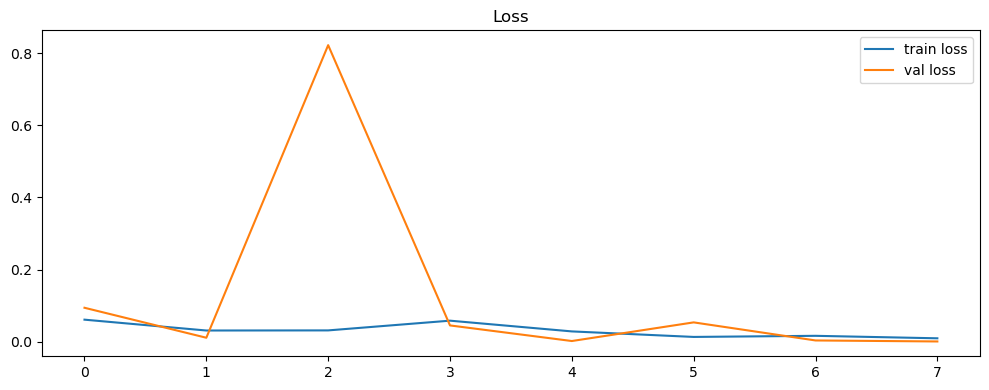

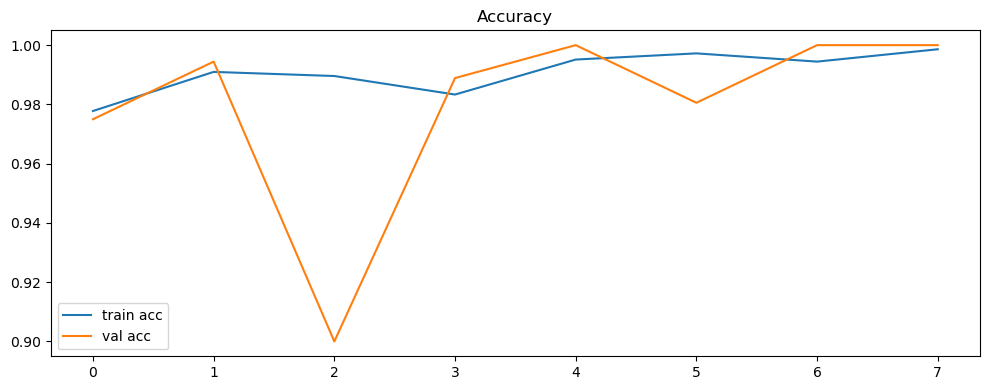

In [24]:
import matplotlib.pyplot as plt

# Ensure output directory exists
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Plot loss
FIG_PATH = FIG_DIR / "loss.png"

plt.figure(figsize=(10,4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()


# Plot accuracy
FIG_PATH = FIG_DIR / "accuracy.png"

plt.figure(figsize=(10,4))
plt.plot(history["train_acc"], label="train acc")
plt.plot(history["val_acc"], label="val acc")
plt.title("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

## Confusion Matrix

To better understand model performance across defect categories, I computes a **confusion matrix** using predictions from the validation dataset.

The confusion matrix shows:

- how many images were correctly classified
- which defect classes are occasionally confused with others

This provides a more detailed view of performance than accuracy alone.

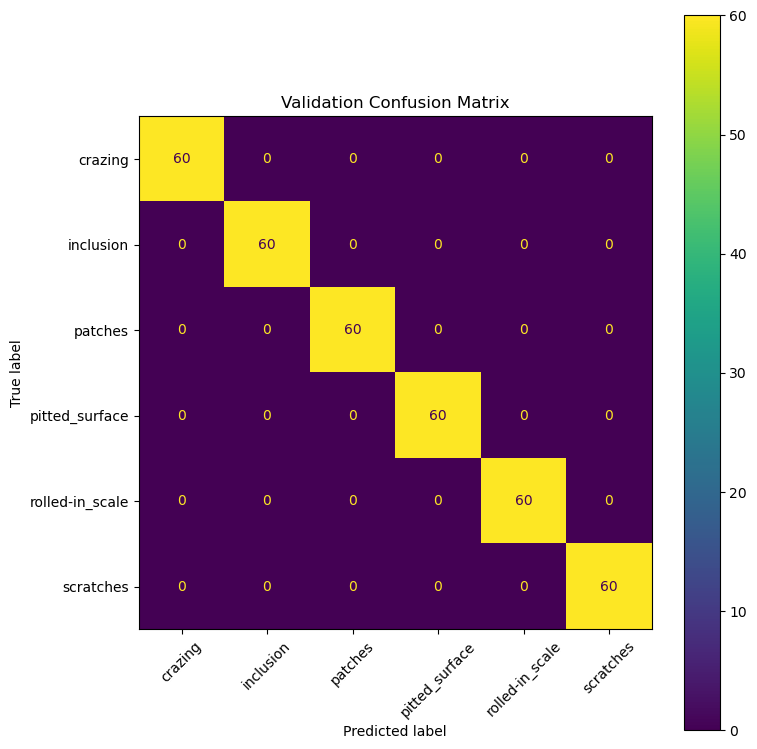

In [25]:
@torch.no_grad()
def get_preds_labels(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)

preds, labels = get_preds_labels(model, val_loader, device)

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_ds.classes)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, xticks_rotation=45, values_format='d')
plt.title("Validation Confusion Matrix")
plt.tight_layout()

# Save the figure to the ouput folder
CM_PATH = PROJECT_ROOT / "outputs" / "figures" / "confusion_matrix.png"
CM_PATH.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(CM_PATH, dpi=300, bbox_inches="tight")

plt.show()

## Saving the Trained Model

To ensure the experiment is reproducible, I saved the trained model to disk.

The saved checkpoint contains:

- the trained model weights (`model_state_dict`)
- the class-to-index mapping used by the dataset

Saving the class mapping ensures that predictions can later be converted back to the correct defect labels.

In [26]:
# Path where the trained model will be saved
MODEL_PATH = PROJECT_ROOT / "outputs" / "models" / "resnet18_neu_defects.pt"

# Ensure directory exists
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": train_ds.class_to_idx
}, MODEL_PATH)

print("Saved model to:", MODEL_PATH)

Saved model to: /Users/royphelps/Library/CloudStorage/OneDrive-DrexelUniversity/CS-614-900/Assignments/Final Project/CS614-AI-Industrial-Quality-Inspector/outputs/models/resnet18_neu_defects.pt


# 7. Demo and Predictions

## Demo Predictions

To qualitatively evaluate model performance, we display predictions on a small sample of validation images.

For each image, we show:

- the **true defect class**
- the **predicted class**
- the **prediction confidence**

Images are de-normalized before visualization so they appear in their original color space.

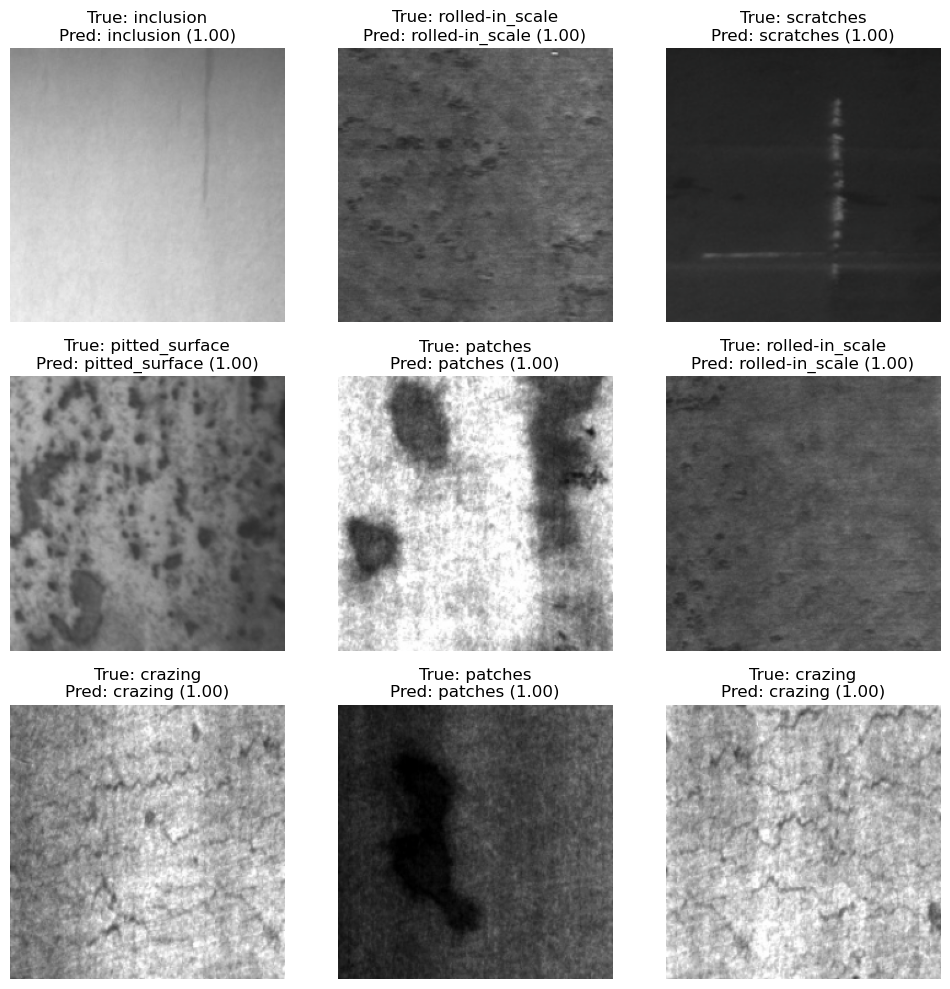

In [28]:
import torch.nn.functional as F

@torch.no_grad()
def demo_predictions(model, ds, n=9, seed=42):
    model.eval()
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(ds), size=n, replace=False)

    cols = 3
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(10, 10))

    for i, idx in enumerate(idxs, start=1):
        x, y = ds[idx]
        x_in = x.unsqueeze(0).to(device)

        logits = model(x_in)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        pred = int(np.argmax(probs))
        conf = float(np.max(probs))

        # de-normalize for display (because we normalized for ResNet)
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img = x.permute(1,2,0).cpu().numpy()
        img = (img * std) + mean
        img = np.clip(img, 0, 1)

        title = f"True: {ds.classes[y]}\nPred: {ds.classes[pred]} ({conf:.2f})"

        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()

    # Save the images to the output folder
    DEMO_PATH = PROJECT_ROOT / "outputs" / "figures" / "demo_predictions.png"
    DEMO_PATH.parent.mkdir(parents=True, exist_ok=True)

    plt.savefig(DEMO_PATH, dpi=300, bbox_inches="tight")
    
    plt.show()

demo_predictions(model, val_ds, n=9)

# 8. Grad-CAM Explainability

To improve interpretability, I apply **Grad-CAM (Gradient-weighted Class Activation Mapping)**.

Grad-CAM highlights the image regions that most strongly influence the model's prediction.

This helps answer an important question:

**"What part of the image did the neural network use to make its decision?"**

For industrial inspection systems, explainability is important because it allows engineers to verify that the model is focusing on the actual defect rather than irrelevant background patterns.

I generated Grad-CAM visualizations by:

1. Passing an image through the trained ResNet18 model
2. Capturing gradients from the final convolution layer (`layer4`)
3. Computing a weighted activation map
4. Overlaying the heatmap on the original image

The result is a heatmap highlighting the regions most responsible for the predicted defect classification.

In [31]:
# Install opencv-python if needed.  Just uncomment the below.
#!pip install opencv-python

import cv2

def generate_gradcam(model, image_tensor, target_layer):
    model.eval()

    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    # Register hooks
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)

    # Forward pass
    output = model(image_tensor)
    pred_class = output.argmax(dim=1)

    # Backward pass
    model.zero_grad()
    output[0, pred_class].backward()

    # Get gradients and activations
    grads = gradients[0]
    acts = activations[0]

    weights = grads.mean(dim=(2,3), keepdim=True)

    cam = (weights * acts).sum(dim=1)
    cam = torch.relu(cam)

    cam = cam.squeeze().detach().cpu().numpy()
    cam = cam - cam.min()
    cam = cam / cam.max()

    # Remove hooks
    forward_handle.remove()
    backward_handle.remove()

    return cam, pred_class.item()

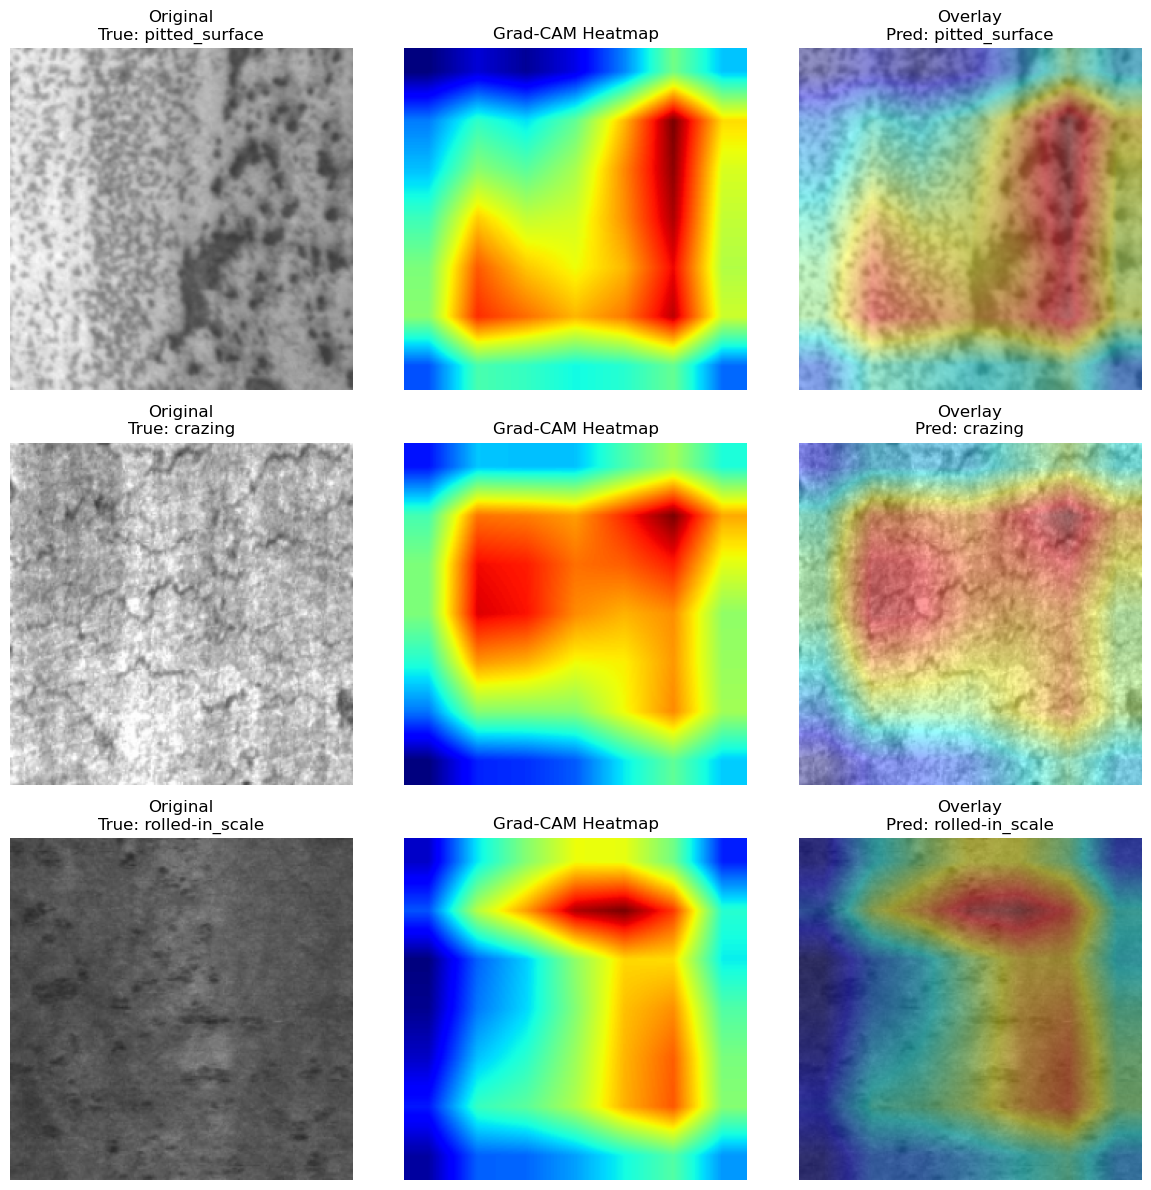

In [34]:
def show_gradcam_examples(model, dataset, n=3, seed=42):
    rng = np.random.default_rng(seed)

    idxs = rng.choice(len(dataset), size=n, replace=False)

    target_layer = model.layer4[-1]

    plt.figure(figsize=(12,4*n))

    for i, idx in enumerate(idxs):

        x, y = dataset[idx]
        x_in = x.unsqueeze(0).to(device)

        cam, pred = generate_gradcam(model, x_in, target_layer)

        # Convert tensor image back to numpy
        img = x.permute(1,2,0).cpu().numpy()

        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])

        img = (img * std) + mean
        img = np.clip(img, 0, 1)

        cam = cv2.resize(cam, (img.shape[1], img.shape[0]))

        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = heatmap[..., ::-1] / 255

        overlay = 0.6 * img + 0.4 * heatmap
        overlay = np.clip(overlay, 0, 1)

        plt.subplot(n,3,3*i+1)
        plt.imshow(img)
        plt.title(f"Original\nTrue: {dataset.classes[y]}")
        plt.axis("off")

        plt.subplot(n,3,3*i+2)
        plt.imshow(cam, cmap="jet")
        plt.title("Grad-CAM Heatmap")
        plt.axis("off")

        plt.subplot(n,3,3*i+3)
        plt.imshow(overlay)
        plt.title(f"Overlay\nPred: {dataset.classes[pred]}")
        plt.axis("off")

    plt.tight_layout()

    CAM_PATH = PROJECT_ROOT / "outputs" / "figures" / "gradcam_examples.png"
    CAM_PATH.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(CAM_PATH, dpi=300, bbox_inches="tight")

    plt.show()

show_gradcam_examples(model, val_ds, n=3)

# 9. Discussion

The ResNet18 transfer learning approach performed extremely well on the NEU surface defect dataset, achieving high classification accuracy across all defect categories.

The confusion matrix indicates that the model successfully distinguishes between visually similar defect types. Additionally, Grad-CAM visualizations confirm that the model focuses on the defect regions rather than background textures.

These results demonstrate that transfer learning can provide an effective and efficient approach for automated industrial surface inspection.

Future work could explore:
- larger industrial datasets
- real-time deployment on production lines
- object detection models such as Faster R-CNN or YOLO for defect localization.

# 10. Reproducibility

## How to Run This Project

To reproduce the results from this project:

### 1. Clone the repository


git clone https://github.com/royphelps1/CS614-AI-Industrial-Quality-Inspector

cd CS614-AI-Industrial-Quality-Inspector


### 2. Install dependencies

Install the required Python packages:

```
pip install -r requirements.txt
```

### 3. Download the dataset

Download the **NEU Surface Defect Dataset** from Kaggle:

https://www.kaggle.com/datasets/bobweng/neu-surface-defect-dataset

Place the dataset in the following directory structure:

```
data/raw/neu_surface_defects/NEU-DET/
    train/images/
    validation/images/
```

### 4. Run the notebook

Open and run the notebook:

```
notebooks/Final Project.ipynb
```

Execute all cells from top to bottom.

### 5. Outputs

After running the notebook:

The trained model will be saved to:

```
outputs/models/resnet18_neu_defects.pt
```

Generated figures (training curves, confusion matrix, Grad-CAM visualizations) will be saved to:

```
outputs/figures/
```